In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, ttest_rel

import warnings
warnings.filterwarnings("ignore")

# ── palette ───────────────────────────────────────────────────────────────────
BLUE      = "#1B4F8A"
BLUE_FILL = "#A8C4E0"
RED       = "#e6550d"
RED_MRK   = "#C0392B"
GREEN     = "#2ca02c"
ORANGE    = "#E67E22"
GRAY      = "#888888"
DKGRAY    = "#555555"

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
    'figure.dpi': 150, 'savefig.dpi': 300,
})

## What happens when companies start reporting?

Identify firms that transition from estimated → disclosed emissions. Compare the Trucost estimate
and our MNAR-adjusted estimate (from the year before disclosure) against the actual disclosed value.

In [2]:
from pathlib import Path

DIR_PROC    = Path("../data/processed");       DIR_PROC.mkdir(parents=True, exist_ok=True)

read_path_lm = DIR_PROC / "df_lm_avg_baseline_wti_gind.parquet"
read_path_gam = DIR_PROC / "df_gam_avg_baseline_wti_gind.parquet"

df_final = pd.read_parquet(
    read_path_lm,
    engine="pyarrow"
)

df_final_gam = pd.read_parquet(
    read_path_gam,
    engine="pyarrow"
)

# Align column names with old repo conventions
for df in [df_final]:
    df['sc1'] = df['sc1_disclosed']
    df['sc1'] = np.where(df['sc1'].isna(), df['sc1_estimated'], df['sc1'])
    df['sc1_disclosed_filled'] = df['sc1_disclosed_complete']

print(f"LM panel: {df_final.shape}")
print(f"GAM panel: {df_final_gam.shape}")

LM panel: (51355, 50)
GAM panel: (51355, 48)


### Detect transition firms

A "clean" transition: firm was only estimated before, then switches to disclosed, and stays disclosed after.

In [3]:
check_transition = df_final[df_final['year'] < 2023].copy()
check_transition = check_transition.dropna(subset=['sc1_disclosed', 'sc1_estimated'], how='all')

# Sort and create lagged/lead variables
check_transition = check_transition.sort_values(by=['gvkey', 'year']).reset_index(drop=True)
check_transition["sc1_estimated_t-1"] = check_transition.groupby("gvkey")["sc1_estimated"].shift(1)
check_transition["sc1_ours_t-1"] = check_transition.groupby("gvkey")["sc1_ours"].shift(1)
check_transition["sc1_estimated_t+1"] = check_transition.groupby("gvkey")["sc1_estimated"].shift(-1)
check_transition["at_t-1"] = check_transition.groupby("gvkey")["at"].shift(1)

# Label observation type
check_transition['type'] = 'missing'
check_transition.loc[check_transition['sc1_estimated'].notna(), 'type'] = 'estimated'
check_transition.loc[check_transition['sc1_disclosed'].notna(), 'type'] = 'disclosed'


def detect_strict_transition(group):
    """Find firms with exactly one estimated → disclosed transition and no reversals."""
    group = group.sort_values("year").copy()
    group["type"] = "missing"
    group.loc[group["sc1_estimated"].notna(), "type"] = "estimated"
    group.loc[group["sc1_disclosed"].notna(), "type"] = "disclosed"
    types = group["type"].values

    transition_indices = [
        i for i in range(1, len(types))
        if types[i-1] == "estimated" and types[i] == "disclosed"
    ]

    if len(transition_indices) == 1:
        idx = transition_indices[0]
        before = types[:idx]
        after = types[idx+1:]
        if (all(t in ['estimated', 'missing'] for t in before)
                and not any(t == 'estimated' for t in after)):
            return group.iloc[[idx]]
    return None


valid_transitions = (
    check_transition
    .groupby('gvkey', group_keys=False)
    .apply(detect_strict_transition)
    .dropna(how='all')
    .reset_index(drop=True)
)

print(f"Found {len(valid_transitions)} clean transitions across "
      f"{valid_transitions['gvkey'].nunique()} firms")

Found 654 clean transitions across 654 firms


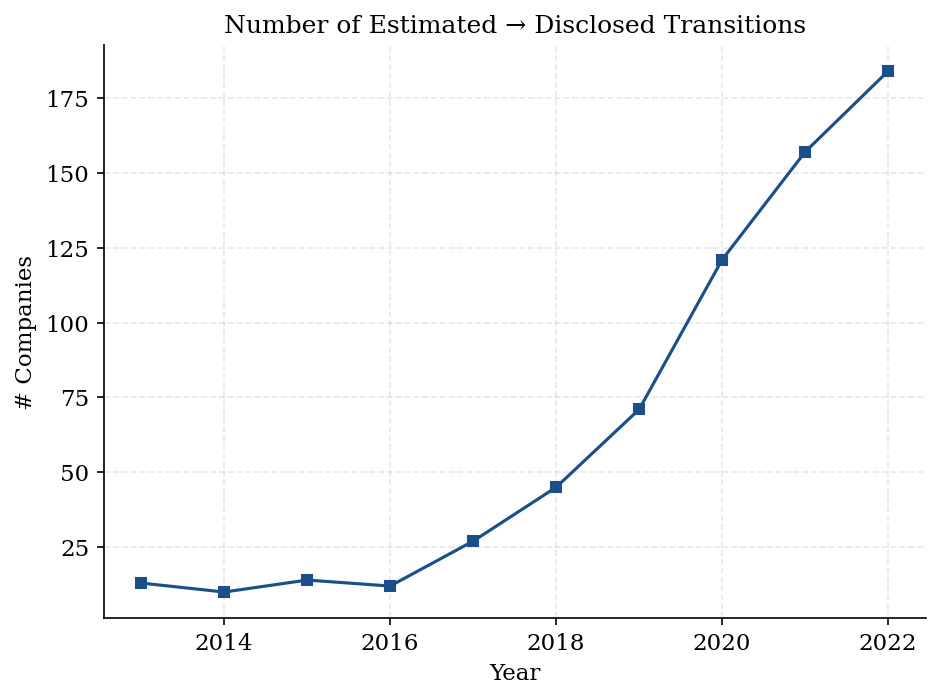

In [4]:
fig, ax = plt.subplots()
valid_transitions.groupby('year').gvkey.nunique().plot(
    marker='s', markersize=5, color=BLUE, ax=ax)
ax.set_ylabel("# Companies")
ax.set_xlabel("Year")
ax.set_title("Number of Estimated \u2192 Disclosed Transitions")
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

### Prediction errors: Trucost vs MNAR

Compare the relative error of the Trucost estimate (t-1) and our MNAR estimate (t-1) against the actual disclosed value at time t.

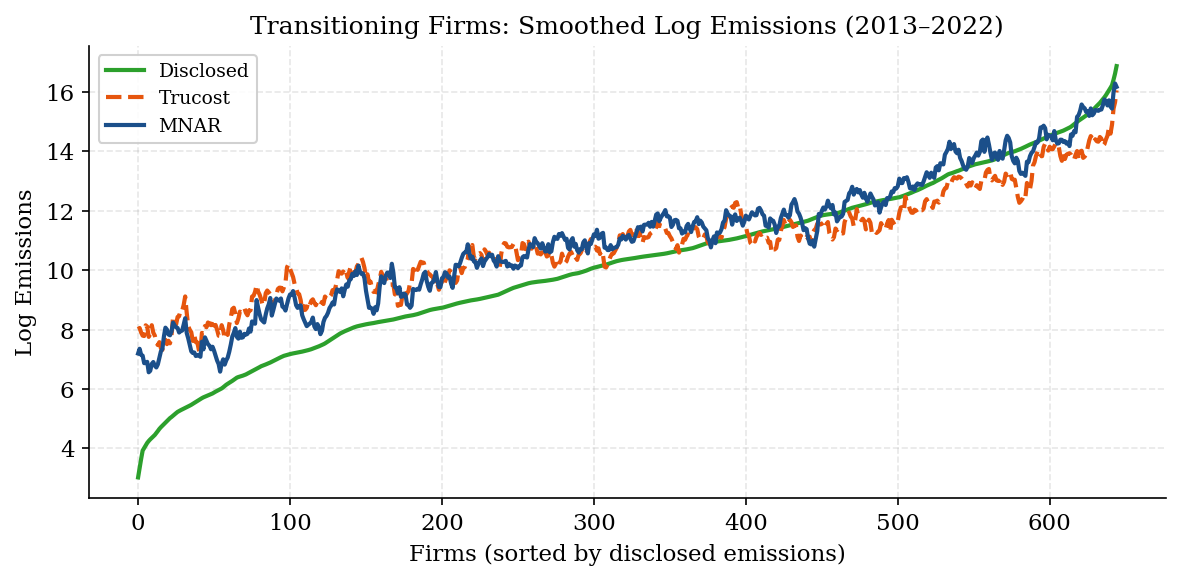

In [5]:
window = 10

df_sorted = valid_transitions.sort_values(by='sc1_disclosed').reset_index(drop=True)

def smooth(arr):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(smooth(np.log(df_sorted['sc1_disclosed'])),    color=GREEN, lw=2, label='Disclosed')
ax.plot(smooth(np.log(df_sorted['sc1_estimated_t-1'])), color=RED,  lw=2, linestyle='--', label='Trucost')
ax.plot(smooth(np.log(df_sorted['sc1_ours_t-1'])),      color=BLUE, lw=2, label='MNAR')

ax.set_xlabel("Firms (sorted by disclosed emissions)")
ax.set_ylabel("Log Emissions")
ax.set_title("Transitioning Firms: Smoothed Log Emissions (2013\u20132022)")
ax.grid(alpha=0.3, linestyle="--")
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

Firms after trimming: 406

Level errors:     MNAR mean=1.049  Trucost mean=0.986
  t-test p=0.821

Intensity errors: MNAR mean=1.097  Trucost mean=1.046
  t-test p=0.762


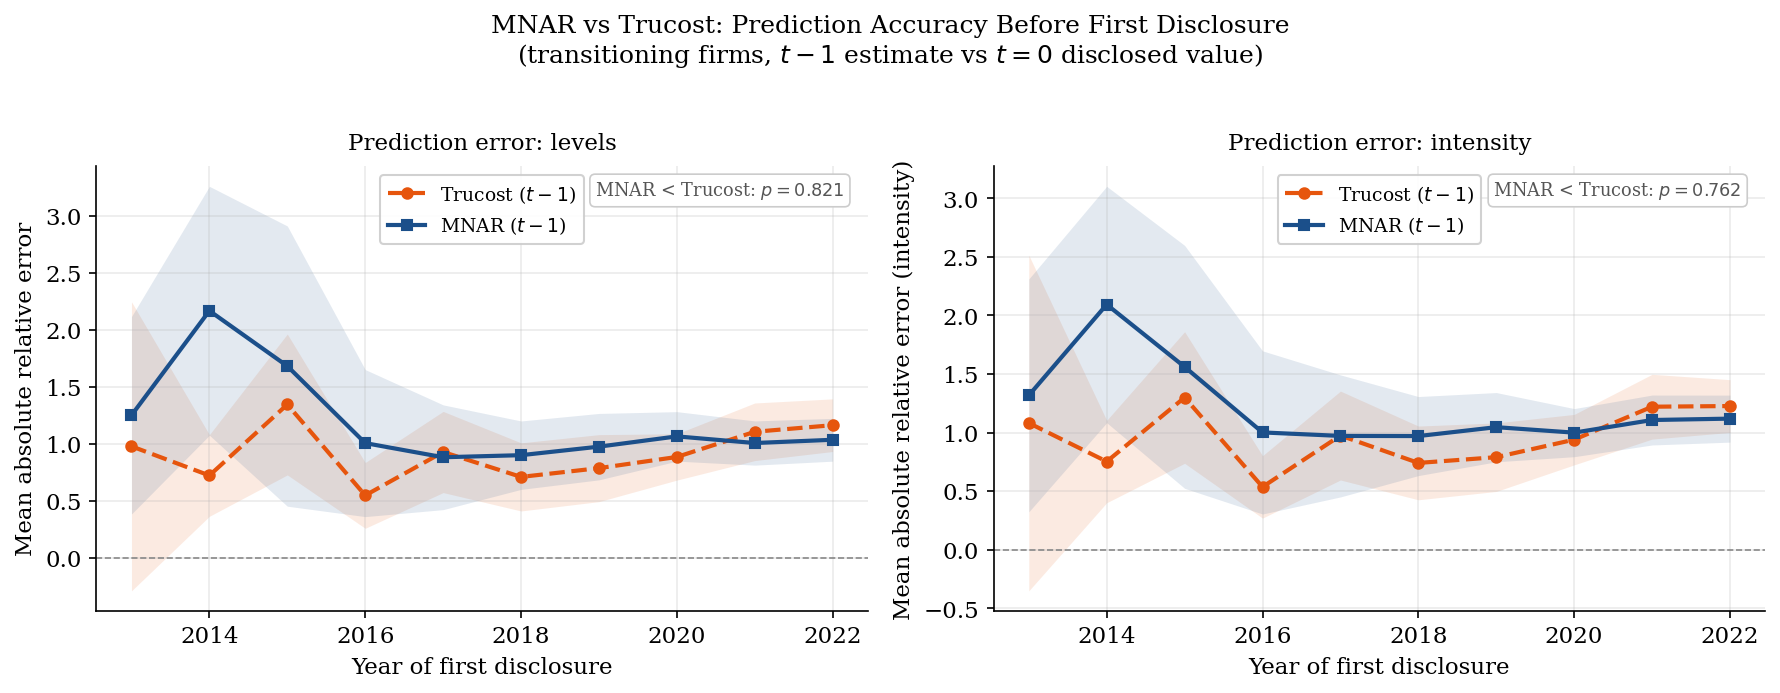

In [6]:
# ── compute errors ────────────────────────────────────────────────────────────
valid_transitions["error_estimated"] = (
    (valid_transitions["sc1_estimated_t-1"] - valid_transitions["sc1_disclosed"]).abs()
    / valid_transitions["sc1_disclosed"]
)
valid_transitions["error_ours"] = (
    (valid_transitions["sc1_ours_t-1"] - valid_transitions["sc1_disclosed"]).abs()
    / valid_transitions["sc1_disclosed"]
)

valid_transitions["intensity_disclosed"] = valid_transitions["sc1_disclosed"] / valid_transitions["at"]
valid_transitions["intensity_estimated_t-1"] = valid_transitions["sc1_estimated_t-1"] / valid_transitions["at_t-1"]
valid_transitions["intensity_ours_t-1"] = valid_transitions["sc1_ours_t-1"] / valid_transitions["at_t-1"]

valid_transitions["error_estimated_intensity"] = (
    (valid_transitions["intensity_estimated_t-1"] - valid_transitions["intensity_disclosed"]).abs()
    / valid_transitions["intensity_disclosed"]
)
valid_transitions["error_ours_intensity"] = (
    (valid_transitions["intensity_ours_t-1"] - valid_transitions["intensity_disclosed"]).abs()
    / valid_transitions["intensity_disclosed"]
)

def remove_outliers_iqr(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

vt = valid_transitions.copy()
for col in ["error_estimated", "error_ours", "error_estimated_intensity", "error_ours_intensity"]:
    vt = remove_outliers_iqr(vt, col)
print(f"Firms after trimming: {len(vt):,}")

# ── formal tests ─────────────────────────────────────────────────────────────
tt_level = ttest_rel(vt["error_ours"], vt["error_estimated"], alternative="less")
tt_int   = ttest_rel(vt["error_ours_intensity"], vt["error_estimated_intensity"], alternative="less")

print(f"\nLevel errors:     MNAR mean={vt['error_ours'].mean():.3f}  "
      f"Trucost mean={vt['error_estimated'].mean():.3f}")
print(f"  t-test p={tt_level.pvalue:.3f}")
print(f"\nIntensity errors: MNAR mean={vt['error_ours_intensity'].mean():.3f}  "
      f"Trucost mean={vt['error_estimated_intensity'].mean():.3f}")
print(f"  t-test p={tt_int.pvalue:.3f}")

# ── aggregate by year ─────────────────────────────────────────────────────────
err_yr = (vt.groupby("year")
             .agg(est_mean   =("error_estimated",          "mean"),
                  est_se     =("error_estimated",          lambda x: x.std()/len(x)**0.5),
                  ours_mean  =("error_ours",               "mean"),
                  ours_se    =("error_ours",               lambda x: x.std()/len(x)**0.5),
                  est_i_mean =("error_estimated_intensity", "mean"),
                  est_i_se   =("error_estimated_intensity", lambda x: x.std()/len(x)**0.5),
                  ours_i_mean=("error_ours_intensity",      "mean"),
                  ours_i_se  =("error_ours_intensity",      lambda x: x.std()/len(x)**0.5),
                  n          =("error_ours",                "count"))
             .reset_index())

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, y_est, se_est, y_ours, se_ours, title, ylabel in [
    (axes[0],
     err_yr["est_mean"],  err_yr["est_se"],
     err_yr["ours_mean"], err_yr["ours_se"],
     "Prediction error: levels",
     "Mean absolute relative error"),
    (axes[1],
     err_yr["est_i_mean"], err_yr["est_i_se"],
     err_yr["ours_i_mean"],err_yr["ours_i_se"],
     "Prediction error: intensity",
     "Mean absolute relative error (intensity)"),
]:
    yrs = err_yr["year"].values

    ax.plot(yrs, y_est, color=RED, lw=2, marker="o", ms=5,
            linestyle="--", label="Trucost ($t-1$)")
    ax.fill_between(yrs, y_est - 1.96*se_est, y_est + 1.96*se_est,
                    color=RED, alpha=0.12, lw=0)

    ax.plot(yrs, y_ours, color=BLUE, lw=2, marker="s", ms=5,
            label="MNAR ($t-1$)")
    ax.fill_between(yrs, y_ours - 1.96*se_ours, y_ours + 1.96*se_ours,
                    color=BLUE, alpha=0.12, lw=0)

    ax.axhline(0, color=GRAY, lw=0.8, ls="--")
    ax.set_xlabel("Year of first disclosure")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, pad=8)
    ax.legend(fontsize=9, framealpha=0.9)

    p = tt_level.pvalue if ax == axes[0] else tt_int.pvalue
    ax.text(0.97, 0.97, f"MNAR < Trucost: $p = {p:.3f}$",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, color=DKGRAY,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#CCCCCC", lw=0.8))

fig.suptitle(
    "MNAR vs Trucost: Prediction Accuracy Before First Disclosure\n"
    "(transitioning firms, $t-1$ estimate vs $t=0$ disclosed value)",
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Firms after trimming: 524
               error_ours  error_estimated
quintile                                  
Q1\n(lowest)        4.876           11.726
Q2                  2.194            3.348
Q3                  1.741            1.394
Q4                  0.868            0.526
Q5\n(highest)       0.773            0.559

By quintile:
     quintile   n  mnar_lev  truc_lev  p_lev  mnar_int  truc_int  p_int
 Q1\n(lowest) 101     4.876    11.726  0.000     6.207    14.677  0.000
           Q2 106     2.194     3.348  0.001     2.475     3.883  0.001
           Q3 109     1.741     1.394  0.935     1.927     1.517  0.938
           Q4 101     0.868     0.526  1.000     0.904     0.565  1.000
Q5\n(highest) 107     0.773     0.559  0.999     0.881     0.573  0.994


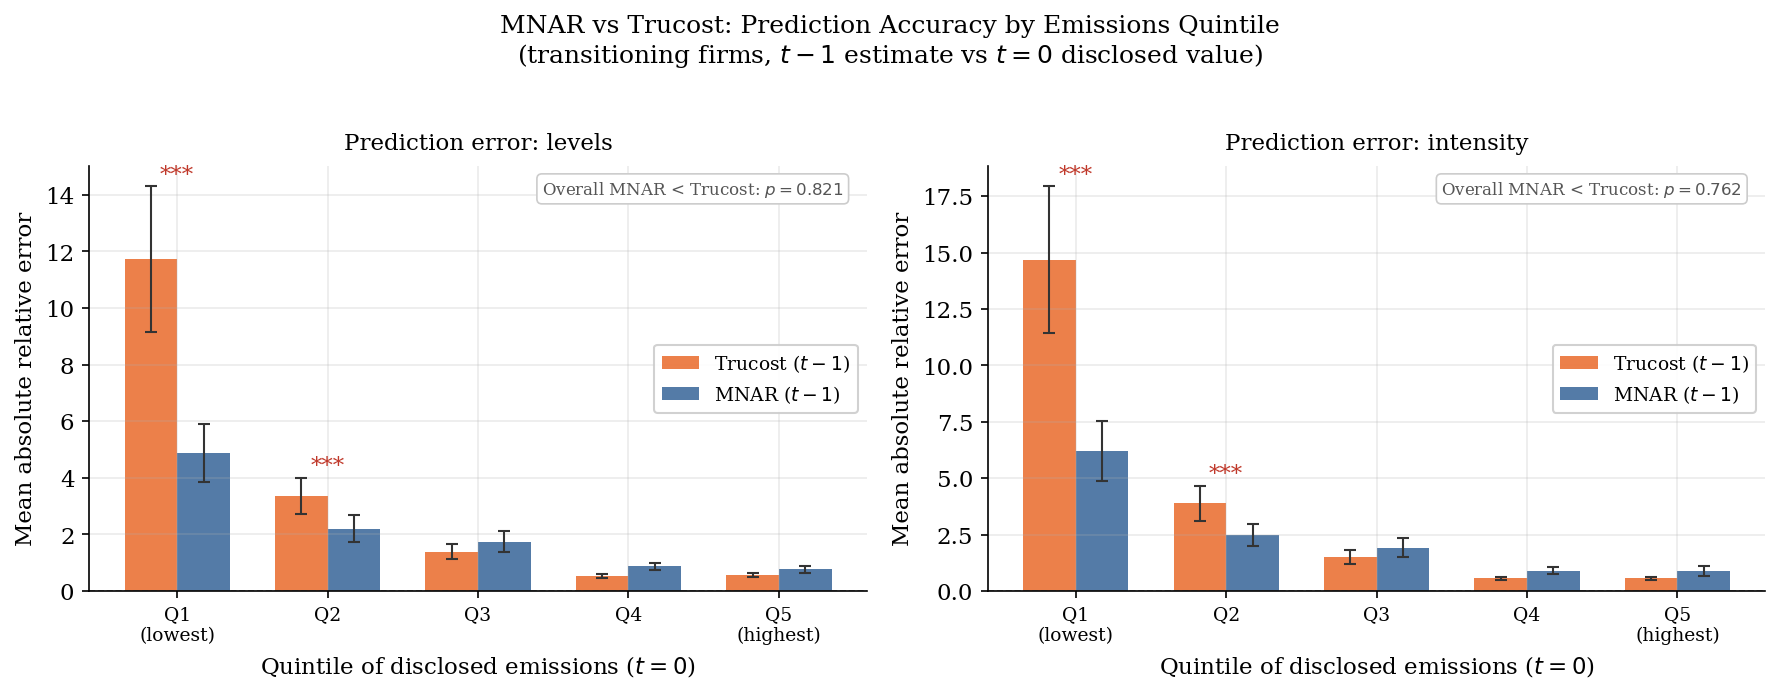

In [7]:
# ── quintiles based on disclosed emissions at t=0 ────────────────────────────
vt = valid_transitions.copy()
vt["quintile"] = pd.qcut(vt["sc1_disclosed"], q=5,
                          labels=["Q1\n(lowest)", "Q2", "Q3", "Q4", "Q5\n(highest)"])

vt_q = (vt.groupby("quintile", group_keys=False)
           .apply(lambda g: remove_outliers_iqr(
               remove_outliers_iqr(g, "error_estimated"), "error_ours"))
           .reset_index(drop=True))

print(f"Firms after trimming: {len(vt_q):,}")
print(vt_q.groupby("quintile")[["error_ours", "error_estimated"]].mean().round(3))

# ── formal tests by quintile ─────────────────────────────────────────────────
quintile_tests = []
for q in vt_q["quintile"].cat.categories:
    g = vt_q[vt_q["quintile"] == q]
    if len(g) < 10:
        continue
    tt  = ttest_rel(g["error_ours"], g["error_estimated"], alternative="less")
    tt_i = ttest_rel(g["error_ours_intensity"], g["error_estimated_intensity"],
                     alternative="less")
    quintile_tests.append({
        "quintile": q, "n": len(g),
        "mnar_lev": g["error_ours"].mean(), "truc_lev": g["error_estimated"].mean(),
        "p_lev": tt.pvalue,
        "mnar_int": g["error_ours_intensity"].mean(), "truc_int": g["error_estimated_intensity"].mean(),
        "p_int": tt_i.pvalue,
    })

qt = pd.DataFrame(quintile_tests)
print("\nBy quintile:")
print(qt[["quintile","n","mnar_lev","truc_lev","p_lev",
          "mnar_int","truc_int","p_int"]].round(3).to_string(index=False))

# ── aggregate by quintile ────────────────────────────────────────────────────
err_q = (vt_q.groupby("quintile", observed=True)
              .agg(est_mean   =("error_estimated",          "mean"),
                   est_se     =("error_estimated",          lambda x: x.std()/len(x)**0.5),
                   ours_mean  =("error_ours",               "mean"),
                   ours_se    =("error_ours",               lambda x: x.std()/len(x)**0.5),
                   est_i_mean =("error_estimated_intensity", "mean"),
                   est_i_se   =("error_estimated_intensity", lambda x: x.std()/len(x)**0.5),
                   ours_i_mean=("error_ours_intensity",      "mean"),
                   ours_i_se  =("error_ours_intensity",      lambda x: x.std()/len(x)**0.5),
                   n          =("error_ours",                "count"))
              .reset_index())

# ── figure ────────────────────────────────────────────────────────────────────
x       = np.arange(len(err_q))
xlabels = err_q["quintile"].astype(str).values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, y_est, se_est, y_ours, se_ours, title, ylabel, p_vals in [
    (axes[0],
     err_q["est_mean"],   err_q["est_se"],
     err_q["ours_mean"],  err_q["ours_se"],
     "Prediction error: levels",
     "Mean absolute relative error",
     qt["p_lev"].values),
    (axes[1],
     err_q["est_i_mean"], err_q["est_i_se"],
     err_q["ours_i_mean"],err_q["ours_i_se"],
     "Prediction error: intensity",
     "Mean absolute relative error",
     qt["p_int"].values),
]:
    w = 0.35
    ax.bar(x - w/2, y_est,  width=w, color=RED,  alpha=0.75,
           label="Trucost ($t-1$)", yerr=1.96*se_est, capsize=3,
           error_kw={"elinewidth": 1.0, "ecolor": "#333333"})
    ax.bar(x + w/2, y_ours, width=w, color=BLUE, alpha=0.75,
           label="MNAR ($t-1$)", yerr=1.96*se_ours, capsize=3,
           error_kw={"elinewidth": 1.0, "ecolor": "#333333"})

    for i, p in enumerate(p_vals):
        s = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
        if s:
            y_top = max(y_est.iloc[i] + 1.96*se_est.iloc[i],
                        y_ours.iloc[i] + 1.96*se_ours.iloc[i])
            ax.text(i, y_top + 0.02, s, ha="center", va="bottom",
                    fontsize=11, color=RED_MRK)

    ax.axhline(0, color=GRAY, lw=0.8, ls="--")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_xlabel("Quintile of disclosed emissions ($t=0$)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, pad=8)
    ax.legend(fontsize=9, framealpha=0.9)

    p_all = tt_level.pvalue if ax == axes[0] else tt_int.pvalue
    ax.text(0.97, 0.97, f"Overall MNAR < Trucost: $p = {p_all:.3f}$",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color=DKGRAY,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#CCCCCC", lw=0.8))

fig.suptitle(
    "MNAR vs Trucost: Prediction Accuracy by Emissions Quintile\n"
    "(transitioning firms, $t-1$ estimate vs $t=0$ disclosed value)",
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()